In [59]:
!pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [60]:
#Setup

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("./datasets/all_athlete_games.csv")
regions=pd.read_csv("./datasets/all_regions.csv")
df.shape

C:\Users\anand\AppData\Local\Temp\ipykernel_3192\2451140752.py:8: DtypeWarning: Columns (0: Sport Disciplines, 1: Event List) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("./datasets/all_athlete_games.csv")


(300266, 14)

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300266 entries, 0 to 300265
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Entry ID           300266 non-null  int64  
 1   Name               300266 non-null  str    
 2   Gender             300266 non-null  str    
 3   Age                287876 non-null  float64
 4   Team               297350 non-null  str    
 5   NOC                300266 non-null  str    
 6   Year               300266 non-null  int64  
 7   Season             300266 non-null  str    
 8   City               300266 non-null  str    
 9   Sport              286237 non-null  str    
 10  Event              286237 non-null  str    
 11  Medal              42232 non-null   str    
 12  Sport Disciplines  11113 non-null   str    
 13  Event List         11113 non-null   str    
dtypes: float64(1), int64(2), str(11)
memory usage: 32.1 MB


#all_athlete_games.csv
| Column | Description |
|---|---|
| Entry ID | Unique identifier |
| Name | Athlete name |
| Gender | Male or Female |
| Age | Age at time of participation |
| Team | Country or team name |
| NOC | National Olympic Committee code |
| Year | Year of Olympic Games |
| Season | Summer or Winter |
| City | Host city |
| Sport | Sport name |
| Event | Specific event |
| Medal | Gold, Silver, Bronze or NaN |
| Sport Disciplines | Discipline details |
| Event List | Event details |

In [62]:
df.isna()

,Entry ID,Name,Gender,Age,Team,NOC,Year,Season,City,Sport,Event,Medal,Sport Disciplines,Event List
0,False,False,False,True,False,False,False,False,False,False,False,True,True,True
1,False,False,False,True,False,False,False,False,False,False,False,True,True,True
2,False,False,False,True,False,False,False,False,False,False,False,True,True,True
3,False,False,False,True,False,False,False,False,False,False,False,True,True,True
4,False,False,False,True,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300261,False,False,False,True,True,False,False,False,False,True,True,True,True,True
300262,False,False,False,True,True,False,False,False,False,True,True,True,True,True
300263,False,False,False,True,True,False,False,False,False,True,True,True,True,True
300264,False,False,False,True,True,False,False,False,False,True,True,True,True,True


In [63]:
#A null value is a missing value — a cell that has no data. 
#In Pandas, null values appear as NaN, which stands for Not a Number.
# Most athletes do not win medals — 
#so Medal being NaN simply means no medal won.
# NaN in Age means the historical record did not capture that athlete's age."


# Rules and Properties
# NaN is a float — type(np.nan) returns float. 
# That's why numeric columns become float64 when they have missing values — notice Age is float64, not int.
# NaN is not equal to anything — even itself. np.nan == np.nan returns False. Always use isna() to check for missing values.
# Operations with NaN return NaN — 5 + NaN = NaN.
# Pandas skips NaN in calculations by default — sum(), mean(), etc. ignore NaN unless told otherwise.
# None and NaN are both treated as missing — in Pandas they behave the same way.

NULL HANDLING
isna() — Find Missing Values
isna() returns True where a value is missing, False where it exists

In [64]:
#to count nulls per column in the dataset
print(df.isna().sum())

#to count total missing values in the entire dataset
print(df.isna().sum().sum())

Entry ID                  0
Name                      0
Gender                    0
Age                   12390
Team                   2916
NOC                       0
Year                      0
Season                    0
City                      0
Sport                 14029
Event                 14029
Medal                258034
Sport Disciplines    289153
Event List           289153
dtype: int64
879704


In [65]:
#percentage of nulls or missing % per column
missing_pct= df.isna().sum()/len(df)*100 

#format to decimal places
print(missing_pct.round(2))

#Medal is 85.94% missing — but that is expected. 
#Most athletes compete and do not win. 
#This is called meaningful missingness — the missing value itself tells you something."

Entry ID              0.00
Name                  0.00
Gender                0.00
Age                   4.13
Team                  0.97
NOC                   0.00
Year                  0.00
Season                0.00
City                  0.00
Sport                 4.67
Event                 4.67
Medal                85.94
Sport Disciplines    96.30
Event List           96.30
dtype: float64


In [66]:
#show only columns that have missing values

print(missing_pct[missing_pct>0].sort_values(ascending=False))

Event List           96.298948
Sport Disciplines    96.298948
Medal                85.935138
Sport                 4.672191
Event                 4.672191
Age                   4.126341
Team                  0.971139
dtype: float64


In [67]:
#Find which rows have missing values

rows_with_nulls=df[df.isna().any(axis=1)]
print(rows_with_nulls.shape)

#Here any(axis=1) means any row which has null value.
#In the entire row if there is atleast 1 null value it returns true
#so it shows only rows which has null values

(300266, 14)


In [68]:
#Find non missing values
print(df.notna().sum())

Entry ID             300266
Name                 300266
Gender               300266
Age                  287876
Team                 297350
NOC                  300266
Year                 300266
Season               300266
City                 300266
Sport                286237
Event                286237
Medal                 42232
Sport Disciplines     11113
Event List            11113
dtype: int64


In [69]:
#Filter rows where medal is not null

medal_winners=df[df["Medal"].notna()]
print(medal_winners.shape)
print(medal_winners["Medal"].value_counts())

(42232, 14)
Medal
Gold      14172
Bronze    14162
Silver    13898
Name: count, dtype: int64


In [70]:
#rows where Age is null
df[df['Age'].isna()]

,Entry ID,Name,Gender,Age,Team,NOC,Year,Season,City,Sport,Event,Medal,Sport Disciplines,Event List
0,1,Aristidis Akratopoulos,Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,NaN,NaN,NaN
1,2,Aristidis Akratopoulos,Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,NaN,NaN,NaN
2,3,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,NaN,NaN,NaN
3,4,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,NaN,NaN,NaN
4,5,Anastasios Andreou,Male,NaN,Greece,GRE,1896,Summer,Athina,Athletics,Athletics Men's 110 metres Hurdles,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300261,300262,ZUMWINKLE Grace,Female,NaN,NaN,USA,2026,Winter,Italy,NaN,NaN,NaN,NaN,NaN
300262,300263,ZUNTE Darta,Female,NaN,NaN,EST,2026,Winter,Italy,NaN,NaN,NaN,NaN,NaN
300263,300264,ZURBAY Anabelle,Female,NaN,NaN,IRL,2026,Winter,Italy,NaN,NaN,NaN,NaN,NaN
300264,300265,ZURBRIGGEN Anina,Female,NaN,NaN,BUL,2026,Winter,Italy,NaN,NaN,NaN,NaN,NaN


In [71]:
#rows where Team is not null
df[df['Team'].notna()]


#isnull() and isna are the same,identical function with two names. 
#Same for notnull() and notna(). Use whichever.

,Entry ID,Name,Gender,Age,Team,NOC,Year,Season,City,Sport,Event,Medal,Sport Disciplines,Event List
0,1,Aristidis Akratopoulos,Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,NaN,NaN,NaN
1,2,Aristidis Akratopoulos,Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,NaN,NaN,NaN
2,3,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,NaN,NaN,NaN
3,4,"Konstantinos ""Kostas"" Akratopoulos",Male,NaN,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,NaN,NaN,NaN
4,5,Anastasios Andreou,Male,NaN,Greece,GRE,1896,Summer,Athina,Athletics,Athletics Men's 110 metres Hurdles,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297345,297346,Sefora ADA ETO,Female,21.0,Equatorial Guinea,GEQ,2024,Summer,Paris,NaN,NaN,NaN,['Athletics'],"[""Women's 100m""]"
297346,297347,Emanuela LIUZZI,Female,24.0,Italy,ITA,2024,Summer,Paris,NaN,NaN,NaN,['Wrestling'],"[""Women's Freestyle 50kg""]"
297347,297348,Isayah BOERS,Male,25.0,Netherlands,NED,2024,Summer,Paris,NaN,NaN,NaN,['Athletics'],[4 x 400m Relay Mixed]
297348,297349,Kevin STAUT,Male,43.0,France,FRA,2024,Summer,Paris,NaN,NaN,NaN,['Equestrian'],[Jumping Team]


#Visualising nulls

#Seaborn is a python visualisation library built on top of Matplotlib. It makes the statistical charts easier to create with less code.


sns.heatmap() -A heatmap shows a grid of colors-one color for missing,another for present. On large datasets this gives an instant visual of where nulls are concentrated.

Dark cells=missing. Light cells-present.
One look at it tells you which columns have nulls and are they concentrated in specific rows.

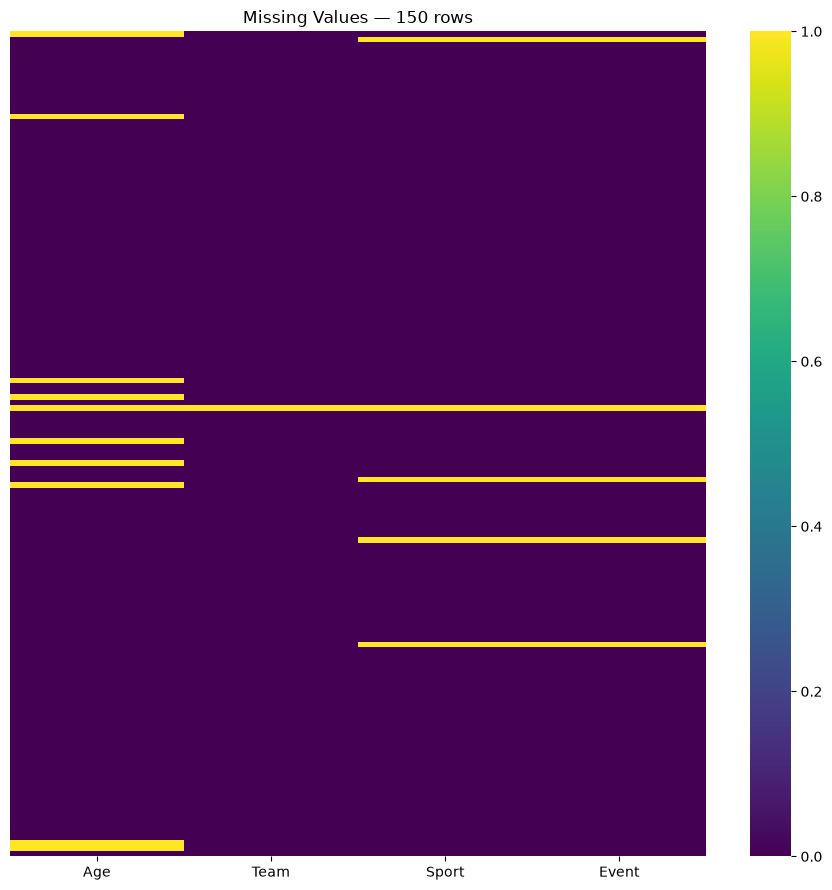

In [72]:
cols = ["Age", "Team", "Sport", "Event"]
sample = df[cols].sample(150, random_state=1)   # fewer rows = more pixel-height per row

plt.figure(figsize=(9, 9))
sns.heatmap(sample.isna(), cbar=True, yticklabels=False, cmap="viridis")  # no linewidths
plt.title("Missing Values — 150 rows")
plt.tight_layout()
plt.show()

| Line | What It Does | New Term |
|---|---|---|
| cols = ["Age", "Team", "Sport", "Event"] | Defines which columns to look at — excludes Medal/Sport Disciplines/Event List since they're mostly empty and would drown out the rest | — |
| df[cols] | Selects only those 4 columns from the full DataFrame | — |
| .sample(150, random_state=1) | Picks 150 random rows out of 300,266 | random_state — a "seed" number that makes the random selection repeatable; same number always picks the same 150 rows |
| sample.isna() | Converts the 150×4 sample into True/False — True where a value is missing | — |
| plt.figure(figsize=(9, 9)) | Creates a 9×9 inch canvas for the plot — taller than default so each of the 150 rows gets more pixel height | figsize — width, height of the figure in inches |
| sns.heatmap(...) | Draws the grid of colored cells from the True/False data | — |
| cbar=False | Hides the color scale bar on the side — not needed since there are only 2 colors (missing/present) | cbar — "color bar," the legend strip next to a heatmap |
| yticklabels=False | Hides row numbers on the left — with 150 rows they'd overlap and be unreadable | — |
| cmap="viridis" | Sets the color scheme — dark purple for False, bright yellow for True | cmap — "colormap," the palette used to turn values into colors |
| linewidths=0.3 | Draws a thin border around every single cell | linewidths — thickness of the gridlines between cells |
| linecolor="white" | Sets that border color to white | — |
| plt.title(...) | Adds the text shown above the plot | — |
| plt.tight_layout() | Auto-adjusts spacing so the title/labels don't get cut off at the edges | tight_layout — shrinks/expands margins to fit everything cleanly |
| plt.show() | Renders and displays the plot | — |

In [73]:
#Dropping the null values

#dropna() - remove rows or columns with nulls

#syntax-
#df.dropna(axis,how,thresh,subset,inplace)

| Argument | Description | Default |
|---|---|---|
| axis | 0 = drop rows, 1 = drop columns | 0 |
| how | "any" = drop if any null, "all" = drop if all null | "any" |
| thresh | Keep rows with at least N non-null values | None |
| subset | Only check these columns for nulls | None — all columns |
| inplace | Modify original DataFrame | False |

In [74]:
print(f"Before:{df.shape}")
df_clean=df.dropna()
print(f"After:{df_clean.shape}")

Before:(300266, 14)
After:(0, 14)


In [75]:
#drop rows only if all values are null

df_clean=df.dropna(how="all")
print(df_clean.shape)

(300266, 14)


In [76]:
#thresh - keep rows with minimum non-null values

df_clean=df.dropna(thresh=8) #keep rows with atleast 8 non-null values
print(f"Before:{df.shape}")
print(f"After:{df_clean.shape}")

Before:(300266, 14)
After:(297350, 14)


In [77]:
#subset- only check specific columns
df_clean=df.dropna(subset=["Age"]) #drop rows where age is null-keep everything else
print(f"Before:{df.shape}")
print(f"After:{df_clean.shape}")

Before:(300266, 14)
After:(287876, 14)


In [78]:
df_clean=df.dropna(subset=["Sport","Event"],how="all") 
#drop rows where both sport and event are null
print(df_clean.shape)

(286237, 14)


In [79]:
#Drop columns with high missing percentage
#keep columns with atleast 50% non null
print(df.columns.tolist())
threshold=len(df)*0.5
df_clean=df.dropna(axis=1,thresh=int(threshold))
print(df_clean.columns.tolist())

['Entry ID', 'Name', 'Gender', 'Age', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'Sport Disciplines', 'Event List']
['Entry ID', 'Name', 'Gender', 'Age', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event']


In [80]:
#safe practice to always work on a copy

df_copy=df.copy()
threshold=len(df)*0.5
df_copy.dropna(axis=1,thresh=int(threshold),inplace=True)
print(df.columns.tolist())
print(df_copy.columns.tolist())

['Entry ID', 'Name', 'Gender', 'Age', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'Sport Disciplines', 'Event List']
['Entry ID', 'Name', 'Gender', 'Age', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event']


In [81]:
#Imputation - filling null values

#Instead of dropping rows with missing values,
# you fill them with a reasonable value. This preserves your data.

#Dropping is destructive,imputation is constructive.
#Use dropping only when the missing data has no reasonable substitute.

#fillna() - fill missing values

#syntax- df["column"].fillna(value,inplace)

In [82]:
#fill the missing data in medal column 
#fill with fixed value

df_copy=df.copy()
print(df["Medal"].value_counts())
df_copy["Medal"]=df_copy["Medal"].fillna("No Medal")
print(df_copy["Medal"].value_counts())

Medal
Gold      14172
Bronze    14162
Silver    13898
Name: count, dtype: int64
Medal
No Medal    258034
Gold         14172
Bronze       14162
Silver       13898
Name: count, dtype: int64


In [83]:
#Fill with mean -best for numeric columns with no extreme outliers

mean_age=df_copy["Age"].mean()
print("Mean age:",round(mean_age,2))
df_copy["Age"]=round(df_copy["Age"].fillna(mean_age),2)
print(df_copy["Age"].isna().sum())

print(df_copy["Age"])

Mean age: 25.66
0
0         25.66
1         25.66
2         25.66
3         25.66
4         25.66
          ...  
300261    25.66
300262    25.66
300263    25.66
300264    25.66
300265    25.66
Name: Age, Length: 300266, dtype: float64


In [84]:
#Fill with median(best for numeric columns with outliers)
df_copy=df.copy()
median_age=df_copy["Age"].median()
print("Median age:",median_age)
df_copy["Age"]=df_copy["Age"].fillna(median_age)
print(df_copy["Age"].isna().sum())

print(df_copy["Age"])


Median age: 25.0
0
0         25.0
1         25.0
2         25.0
3         25.0
4         25.0
          ... 
300261    25.0
300262    25.0
300263    25.0
300264    25.0
300265    25.0
Name: Age, Length: 300266, dtype: float64


In [85]:
#Fill with mode - Best for categorical columns

df_copy=df.copy()
mode_team=df_copy["Team"].mode()[0]
print("Mode[0]:",mode_team)

df_copy["Team"]=df_copy["Team"].fillna(mode_team)
print(df["Team"].isna().sum())
print(df_copy["Team"].isna().sum())


Mode[0]: United States
2916
0


| Method | Use when |
|---|---|
| Mean | Numeric, no extreme outliers, normally distributed |
| Median | Numeric, has outliers or skewed data |
| Mode | Categorical column or discrete numeric |
| Fixed value | You know the correct fill — e.g. Medal → "No Medal" |

In [86]:
#Forward fill - ffill

age_series=pd.Series([23.0,None,None,27.0,None,29.0],
                     index=[1996,2000,2004,2008,2012,2016])

print(age_series)

filled=age_series.ffill()
print(filled)


1996    23.0
2000     NaN
2004     NaN
2008    27.0
2012     NaN
2016    29.0
dtype: float64
1996    23.0
2000    23.0
2004    23.0
2008    27.0
2012    27.0
2016    29.0
dtype: float64


In [87]:
#Backward fill - bfill

age_series=pd.Series([23.0,None,None,27.0,None,29.0],
                     index=[1996,2000,2004,2008,2012,2016])

print(age_series)

filled=age_series.bfill()
print(filled)

1996    23.0
2000     NaN
2004     NaN
2008    27.0
2012     NaN
2016    29.0
dtype: float64
1996    23.0
2000    27.0
2004    27.0
2008    27.0
2012    29.0
2016    29.0
dtype: float64
